# ESA ClearSAR — Exploratory Data Analysis

Understanding bbox size distribution, aspect ratios, spatial patterns, and image characteristics
to inform architecture and augmentation choices.

In [2]:
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image

sns.set_theme(style="whitegrid")
random.seed(42)

ANN_PATH = Path("ClearSAR/data/annotations/instances_train.json")
IMG_DIR  = Path("ClearSAR/data/images/train")

with open(ANN_PATH) as f:
    data = json.load(f)

img_df = pd.DataFrame(data["images"]).rename(columns={"id": "image_id"})
ann_df = pd.DataFrame(data["annotations"])
ann_df[["bx", "by", "bw", "bh"]] = pd.DataFrame(ann_df["bbox"].tolist(), index=ann_df.index)
ann_df = ann_df.merge(img_df[["image_id", "width", "height"]], on="image_id")
ann_df["aspect_ratio"] = ann_df["bw"] / ann_df["bh"].replace(0, np.nan)
ann_df["cx_norm"] = (ann_df["bx"] + ann_df["bw"] / 2) / ann_df["width"]
ann_df["cy_norm"] = (ann_df["by"] + ann_df["bh"] / 2) / ann_df["height"]

# COCO size categories
def size_cat(area):
    if area < 1024:   return "small (<32²)"
    if area < 9216:   return "medium (32²–96²)"
    return "large (>96²)"

ann_df["size_cat"] = ann_df["area"].apply(size_cat)

print(f"Images:      {len(img_df)}")
print(f"Annotations: {len(ann_df)}")
print(ann_df[["bw","bh","area","aspect_ratio"]].describe().round(1))

Images:      3154
Annotations: 9288
           bw      bh      area  aspect_ratio
count  9288.0  9288.0    9288.0        9288.0
mean    107.7    26.4    3848.8          10.8
std      68.1    60.8   10238.8          10.4
min       1.0     1.0       3.0           0.0
25%      31.0     7.0     264.0           2.7
50%     138.0    10.0    1056.0           8.4
75%     165.0    13.0    1925.0          15.7
max     504.0   482.0  132235.0          88.0


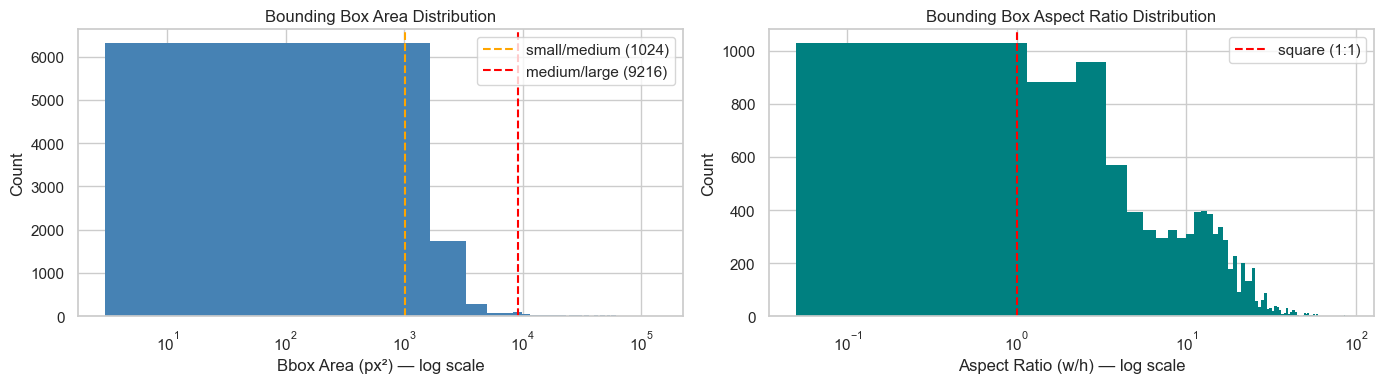


Aspect ratio summary:
  Median: 8.40  Mean: 10.80
  >10 (very wide): 4199 (45.2%)
  <0.1 (very tall): 1 (0.0%)


In [3]:
## 1. Bbox Area & Aspect Ratio Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Area (log scale)
axes[0].hist(ann_df["area"], bins=80, color="steelblue", edgecolor="none")
axes[0].set_xscale("log")
axes[0].set_xlabel("Bbox Area (px²) — log scale")
axes[0].set_ylabel("Count")
axes[0].set_title("Bounding Box Area Distribution")
axes[0].axvline(1024, color="orange", linestyle="--", label="small/medium (1024)")
axes[0].axvline(9216, color="red",    linestyle="--", label="medium/large (9216)")
axes[0].legend()

# Aspect ratio (log scale, clipped for readability)
ar = ann_df["aspect_ratio"].dropna()
ar_clipped = ar.clip(0.05, 100)
axes[1].hist(ar_clipped, bins=80, color="teal", edgecolor="none")
axes[1].set_xscale("log")
axes[1].set_xlabel("Aspect Ratio (w/h) — log scale")
axes[1].set_ylabel("Count")
axes[1].set_title("Bounding Box Aspect Ratio Distribution")
axes[1].axvline(1.0, color="red", linestyle="--", label="square (1:1)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nAspect ratio summary:")
print(f"  Median: {ar.median():.2f}  Mean: {ar.mean():.2f}")
print(f"  >10 (very wide): {(ar > 10).sum()} ({100*(ar > 10).mean():.1f}%)")
print(f"  <0.1 (very tall): {(ar < 0.1).sum()} ({100*(ar < 0.1).mean():.1f}%)")

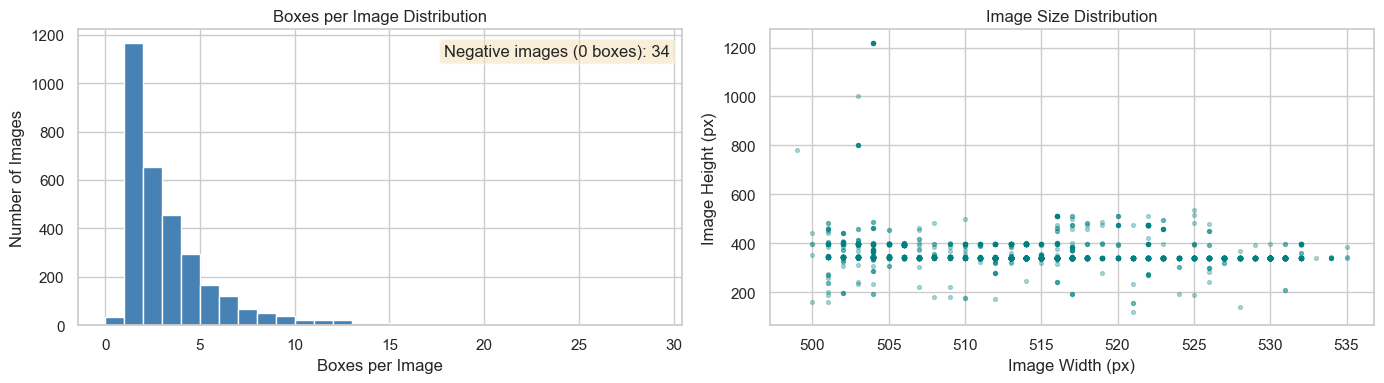


Image size stats:
  Width:  min=499  max=535  mean=516
  Height: min=121  max=1219  mean=354

Boxes per image: mean=2.94  max=28


In [4]:
## 2. Boxes per Image & Image Size Distribution
boxes_per_img = ann_df.groupby("image_id").size()
all_img_ids   = img_df["image_id"]
boxes_per_img = boxes_per_img.reindex(all_img_ids, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Boxes per image histogram
axes[0].hist(boxes_per_img, bins=range(0, boxes_per_img.max() + 2), color="steelblue", edgecolor="white")
axes[0].set_xlabel("Boxes per Image")
axes[0].set_ylabel("Number of Images")
axes[0].set_title("Boxes per Image Distribution")
axes[0].text(0.98, 0.95, f"Negative images (0 boxes): {(boxes_per_img == 0).sum()}",
             transform=axes[0].transAxes, ha="right", va="top",
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

# Image size scatter
axes[1].scatter(img_df["width"], img_df["height"], alpha=0.3, s=8, color="teal")
axes[1].set_xlabel("Image Width (px)")
axes[1].set_ylabel("Image Height (px)")
axes[1].set_title("Image Size Distribution")

plt.tight_layout()
plt.show()

print(f"\nImage size stats:")
print(f"  Width:  min={img_df['width'].min()}  max={img_df['width'].max()}  mean={img_df['width'].mean():.0f}")
print(f"  Height: min={img_df['height'].min()}  max={img_df['height'].max()}  mean={img_df['height'].mean():.0f}")
print(f"\nBoxes per image: mean={boxes_per_img.mean():.2f}  max={boxes_per_img.max()}")

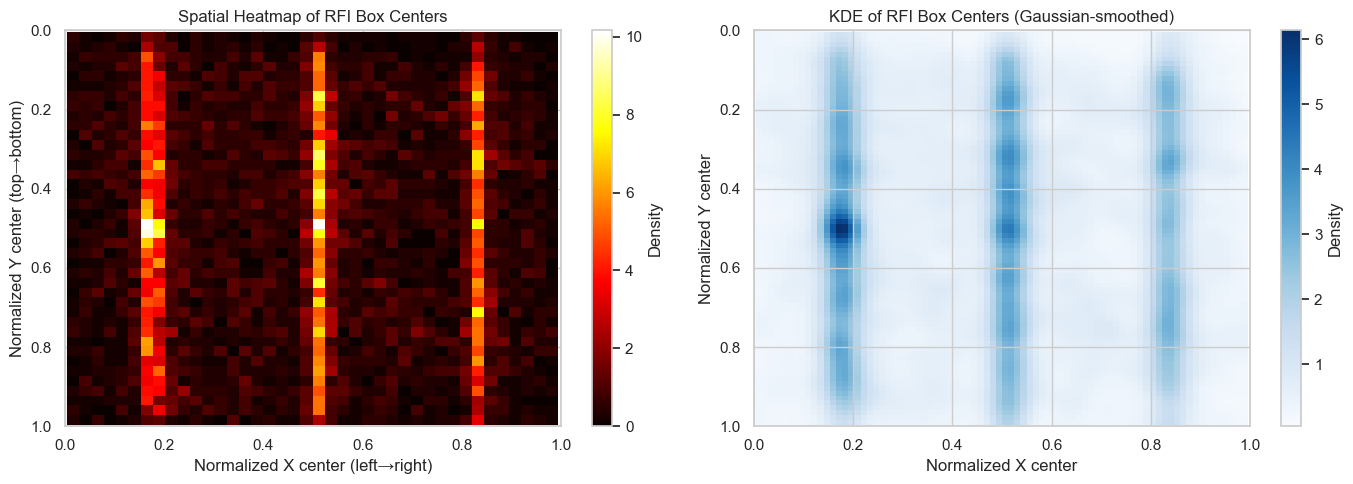

In [5]:
## 3. Spatial Heatmap of Box Centers
from scipy.ndimage import gaussian_filter

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2D histogram heatmap
h = axes[0].hist2d(ann_df["cx_norm"], ann_df["cy_norm"],
                   bins=40, cmap="hot", density=True)
plt.colorbar(h[3], ax=axes[0], label="Density")
axes[0].set_xlabel("Normalized X center (left→right)")
axes[0].set_ylabel("Normalized Y center (top→bottom)")
axes[0].set_title("Spatial Heatmap of RFI Box Centers")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].invert_yaxis()

# Gaussian-smoothed density (replaces kdeplot — avoids contourpy)
counts, xedges, yedges = np.histogram2d(
    ann_df["cx_norm"], ann_df["cy_norm"], bins=80, density=True
)
smoothed = gaussian_filter(counts.T, sigma=2)
im = axes[1].imshow(
    smoothed, origin="upper", aspect="auto", cmap="Blues",
    extent=[xedges[0], xedges[-1], yedges[-1], yedges[0]]
)
plt.colorbar(im, ax=axes[1], label="Density")
axes[1].set_xlabel("Normalized X center")
axes[1].set_ylabel("Normalized Y center")
axes[1].set_title("KDE of RFI Box Centers (Gaussian-smoothed)")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

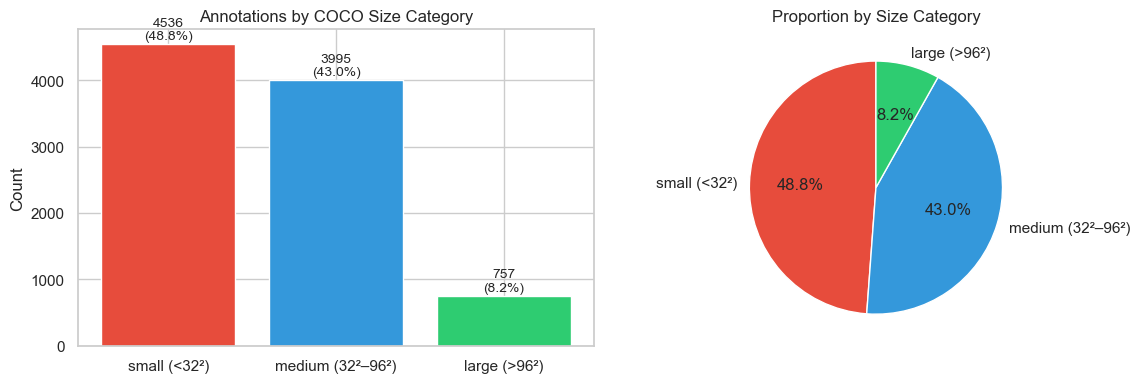


Threshold reference:
  Small : area < 1,024 px²  (bbox < ~32×32)
  Medium: 1,024 ≤ area < 9,216 px²  (32×32 to 96×96)
  Large : area ≥ 9,216 px²  (bbox > ~96×96)


In [6]:
## 4. COCO Size Category Breakdown
size_counts = ann_df["size_cat"].value_counts()
order = ["small (<32²)", "medium (32²–96²)", "large (>96²)"]
size_counts = size_counts.reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(size_counts.index, size_counts.values,
            color=["#e74c3c", "#3498db", "#2ecc71"], edgecolor="white")
axes[0].set_ylabel("Count")
axes[0].set_title("Annotations by COCO Size Category")
for i, (cat, cnt) in enumerate(size_counts.items()):
    axes[0].text(i, cnt + 30, f"{cnt}\n({100*cnt/len(ann_df):.1f}%)",
                 ha="center", va="bottom", fontsize=10)

# Pie chart
axes[1].pie(size_counts.values, labels=size_counts.index,
            colors=["#e74c3c", "#3498db", "#2ecc71"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Proportion by Size Category")

plt.tight_layout()
plt.show()

print("\nThreshold reference:")
print("  Small : area < 1,024 px²  (bbox < ~32×32)")
print("  Medium: 1,024 ≤ area < 9,216 px²  (32×32 to 96×96)")
print("  Large : area ≥ 9,216 px²  (bbox > ~96×96)")

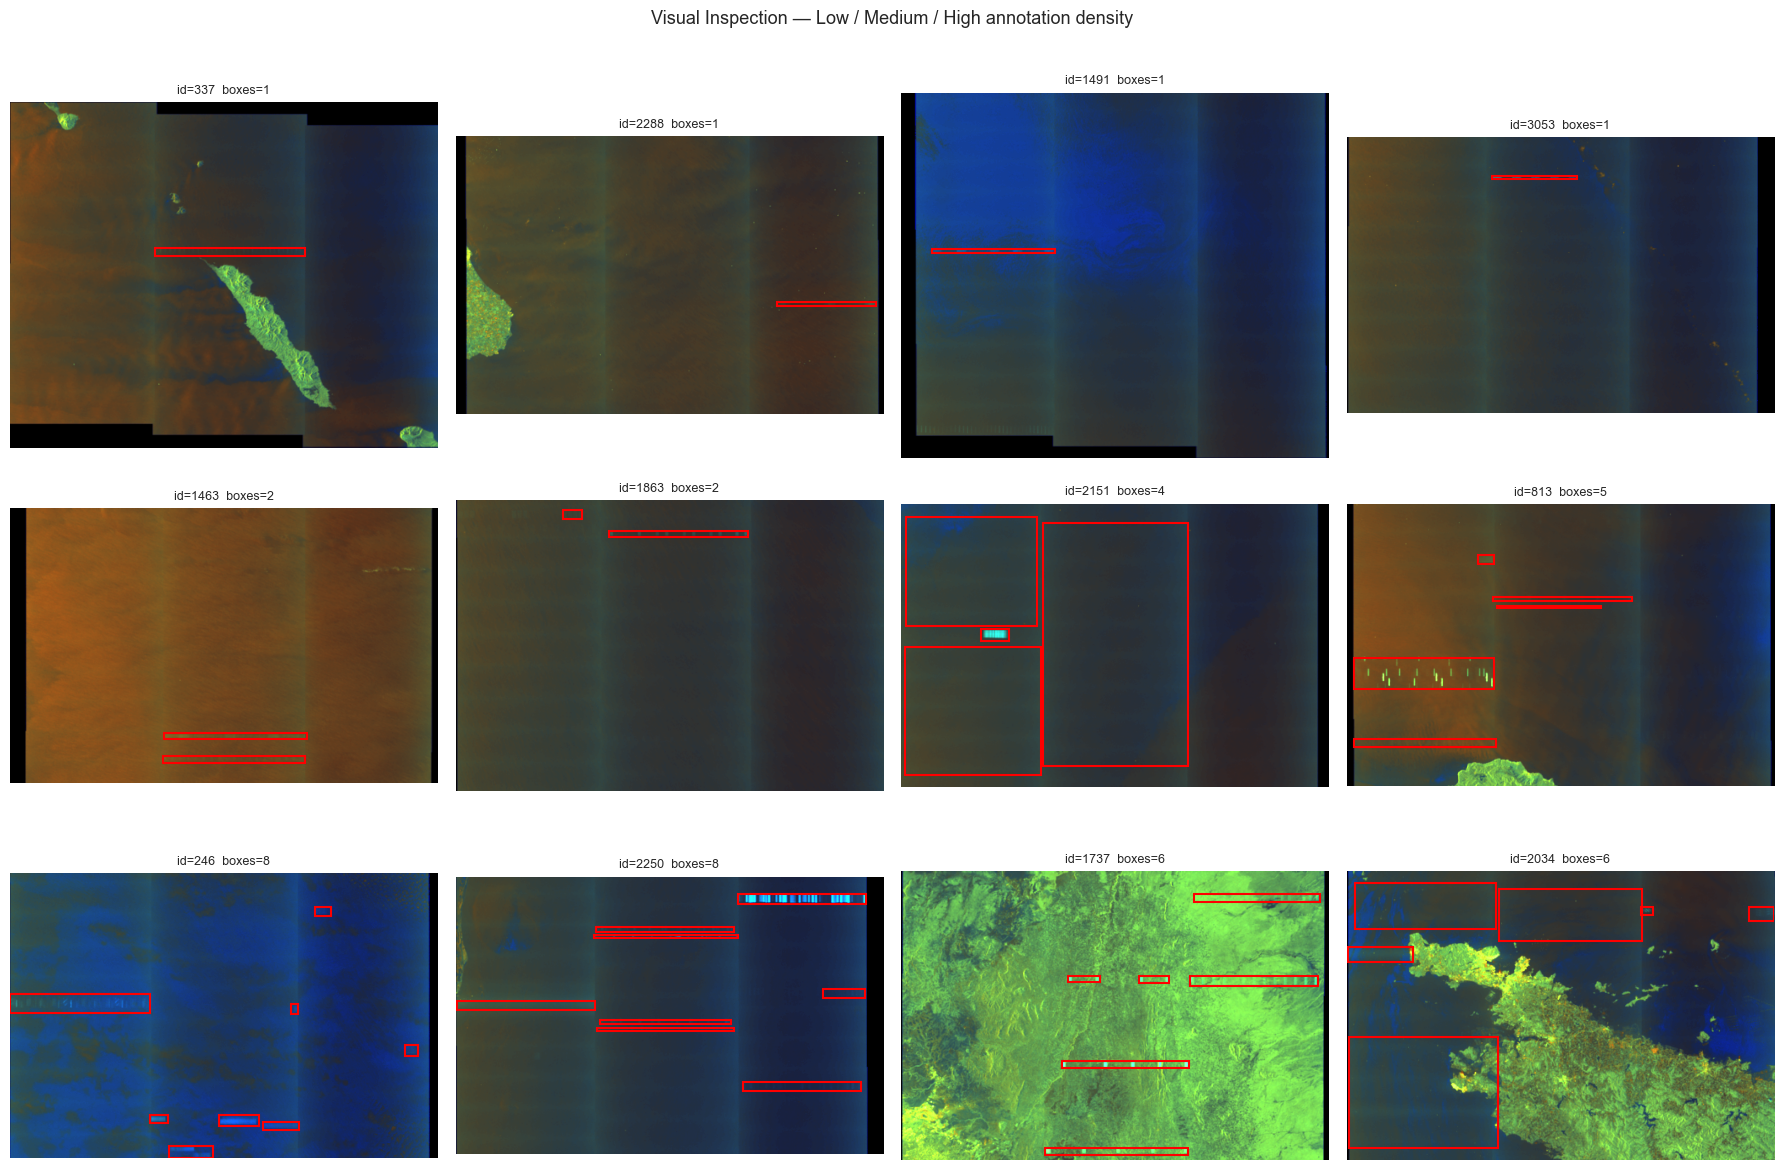

In [7]:
## 5. Visual Inspection — Sample Images with GT Boxes
# Sample 4 images from each group: low (1 box), medium (2-5), high (6+)
low_ids    = boxes_per_img[boxes_per_img == 1].index.tolist()
medium_ids = boxes_per_img[(boxes_per_img >= 2) & (boxes_per_img <= 5)].index.tolist()
high_ids   = boxes_per_img[boxes_per_img >= 6].index.tolist()

sample_ids = (
    random.sample(low_ids,    min(4, len(low_ids)))    +
    random.sample(medium_ids, min(4, len(medium_ids))) +
    random.sample(high_ids,   min(4, len(high_ids)))
)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

ann_by_img = ann_df.groupby("image_id")

for ax, img_id in zip(axes, sample_ids):
    img_path = IMG_DIR / f"{img_id}.png"
    img = Image.open(img_path)
    ax.imshow(img)
    if img_id in ann_by_img.groups:
        for _, row in ann_by_img.get_group(img_id).iterrows():
            rect = patches.Rectangle(
                (row["bx"], row["by"]), row["bw"], row["bh"],
                linewidth=1.5, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)
    n = boxes_per_img[img_id]
    ax.set_title(f"id={img_id}  boxes={n}", fontsize=9)
    ax.axis("off")

# Hide unused axes
for ax in axes[len(sample_ids):]:
    ax.axis("off")

groups = ["Low (1 box)"] * 4 + ["Medium (2–5)"] * 4 + ["High (6+)"] * 4
fig.suptitle("Visual Inspection — Low / Medium / High annotation density", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()